### Assignment-1

In [29]:
## Load the Preprocessed Dataset Here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('../../../data/preprocessed_earthquake_data.csv')
data.head()

,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Minute,Second,Month_sin,Month_cos,Hour_sin,Hour_cos,DayOfWeek_sin,DayOfWeek_cos
0,41.758,23.249,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,4,26,0,8.660254e-01,-0.5,0.500000,-0.866025,0.000000,1.000000
1,41.802,23.108,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,4,2,34,8.660254e-01,-0.5,0.500000,-0.866025,0.000000,1.000000
2,52.763,160.277,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,6,25,0,38,1.224647e-16,-1.0,-0.707107,0.707107,-0.974928,-0.222521
3,51.424,161.638,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,6,25,45,39,1.224647e-16,-1.0,-0.500000,-0.866025,-0.974928,-0.222521
4,30.684,100.608,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,8,30,43,20,-8.660254e-01,-0.5,0.258819,-0.965926,0.781831,0.623490


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

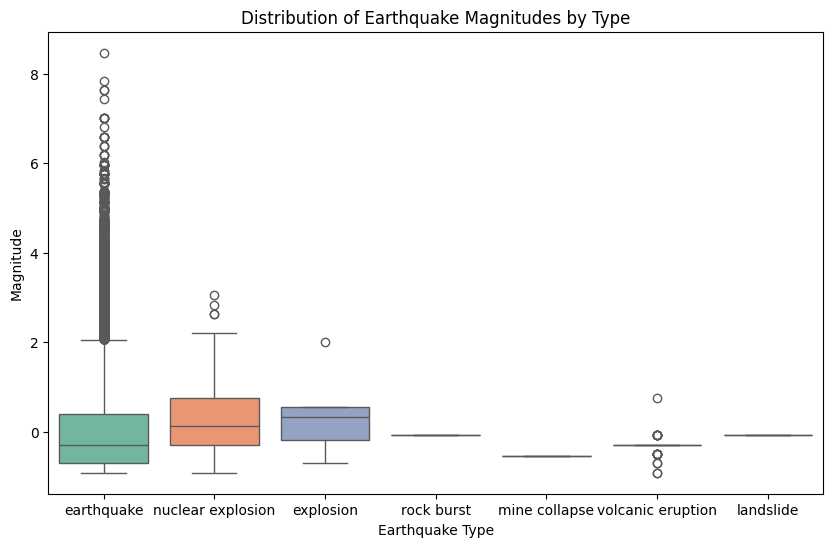

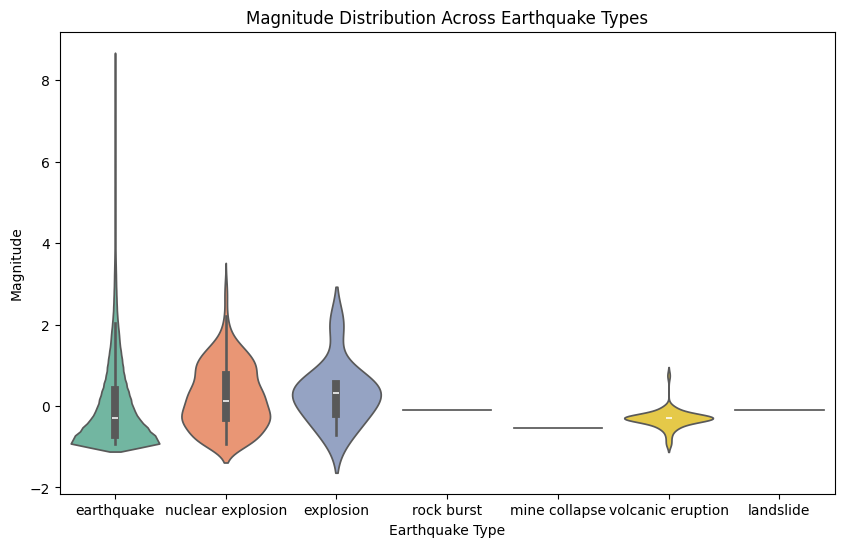

In [30]:
# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='mag', data=data, hue='type', palette='Set2', legend=False)
plt.title('Distribution of Earthquake Magnitudes by Type')
plt.xlabel('Earthquake Type')
plt.ylabel('Magnitude')
plt.show()

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='type', y='mag', data=data, hue='type', palette='Set2', legend=False)
plt.title('Magnitude Distribution Across Earthquake Types')
plt.xlabel('Earthquake Type')
plt.ylabel('Magnitude')
plt.show()

* Most earthquakes in the data are small, with magnitudes between -1 and 2, A few are stronger, between 2 and 8, but those are rare.
* Explosions and nuclear explosions have smaller and more controlled magnitudes, mostly below 3.
*  Rock bursts, mine collapses, and landslides have very few data points, and their magnitudes stay almost the same.
*  Volcanic eruptions show small to medium magnitudes, not too high and not too low, with less variation.

Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

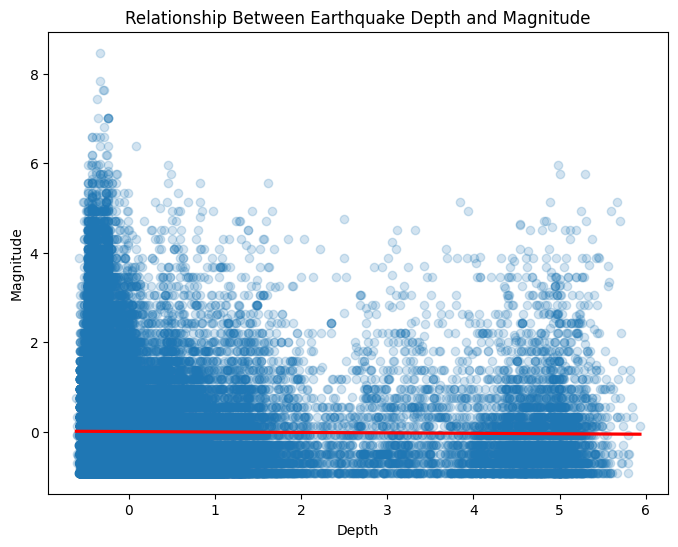

In [31]:
plt.figure(figsize=(8,6))
sns.regplot(x='depth', y='mag', data=data, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Relationship Between Earthquake Depth and Magnitude')
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.show()

* Most earthquakes happen at near the surface, where magnitudes vary from small to high.
* As the depth increases, the number of earthquakes becomes less frequent.
* Most quakes happen near the surface, and some happen deeper, but the middle part has less activity

Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

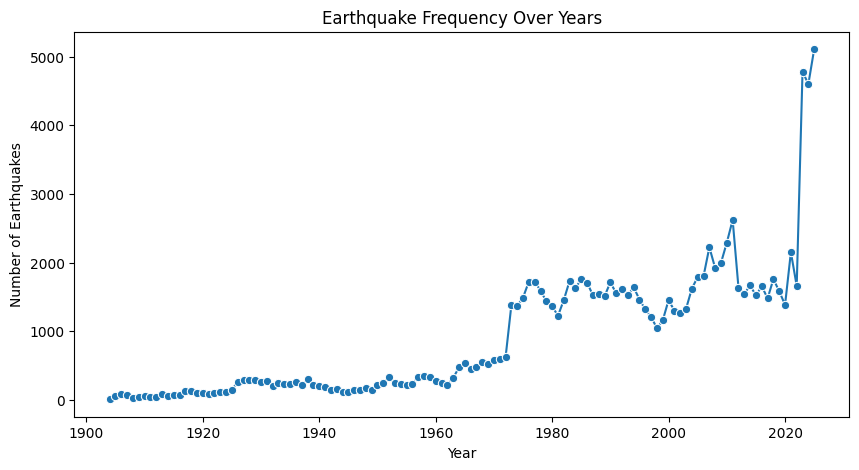

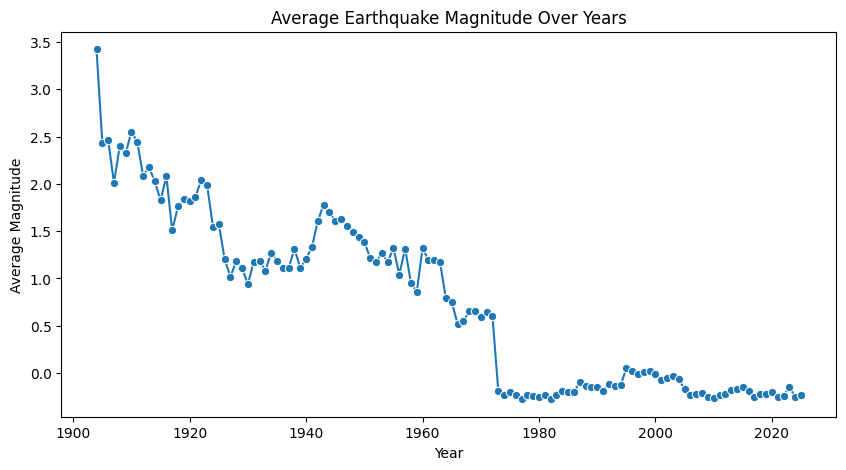

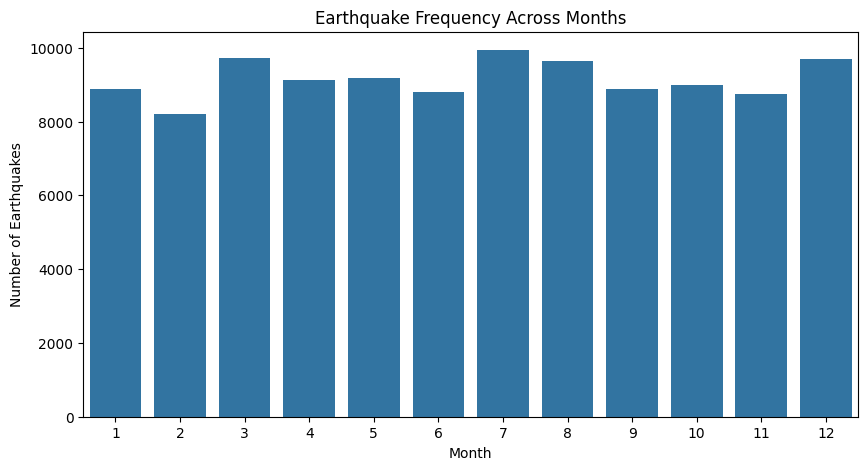

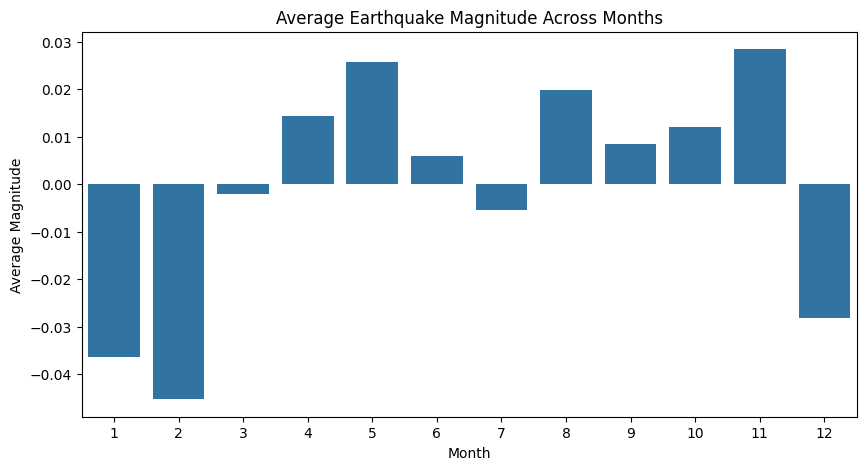

In [32]:
# Earthquake count per year
yearly_counts = data.groupby('Year').size().reset_index(name='Count')

# Average magnitude per year
yearly_mag = data.groupby('Year')['mag'].mean().reset_index(name='Avg_Magnitude')

# Yearly trends 
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Count', data=yearly_counts, marker='o')
plt.title('Earthquake Frequency Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Avg_Magnitude', data=yearly_mag, marker='o')
plt.title('Average Earthquake Magnitude Over Years')
plt.xlabel('Year')
plt.ylabel('Average Magnitude')
plt.show()

# Monthly trends
monthly_counts = data.groupby('Month').size().reset_index(name='Count')
monthly_mag = data.groupby('Month')['mag'].mean().reset_index(name='Avg_Magnitude')

plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='Count', data=monthly_counts)
plt.title('Earthquake Frequency Across Months')
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='Month', y='Avg_Magnitude', data=monthly_mag)
plt.title('Average Earthquake Magnitude Across Months')
plt.xlabel('Month')
plt.ylabel('Average Magnitude')
plt.show()

* very few earthquakes were recorded before 1960, but after 2000 the number shot up sharply, especially after 2020.
* older earthquakes (before 1960) had higher magnitudes, but recent ones are smaller on average.
* after 2000 might be due to better technology and monitoring systems, not just more earthquakes happening naturally.
* The number of earthquakes each month is almost the same, showing no big difference. But the average magnitude changes — from March to November, magnitudes are mostly positive, while in the other months they are negative.

Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

In [33]:
#!pip install plotly
import plotly.express as px
data['mag'] = (data['mag'] - data['mag'].min()) / (data['mag'].max() - data['mag'].min())

fig = px.scatter_geo(
    data,
    lat='latitude',
    lon='longitude',
    color='mag',
    size='mag',
    opacity=0.6,
    size_max=10,
    projection='natural earth',
    color_continuous_scale='Viridis',
    hover_name='type',
    title='Global Earthquake Locations (Transparent Markers)'
)
fig.show(renderer="browser")

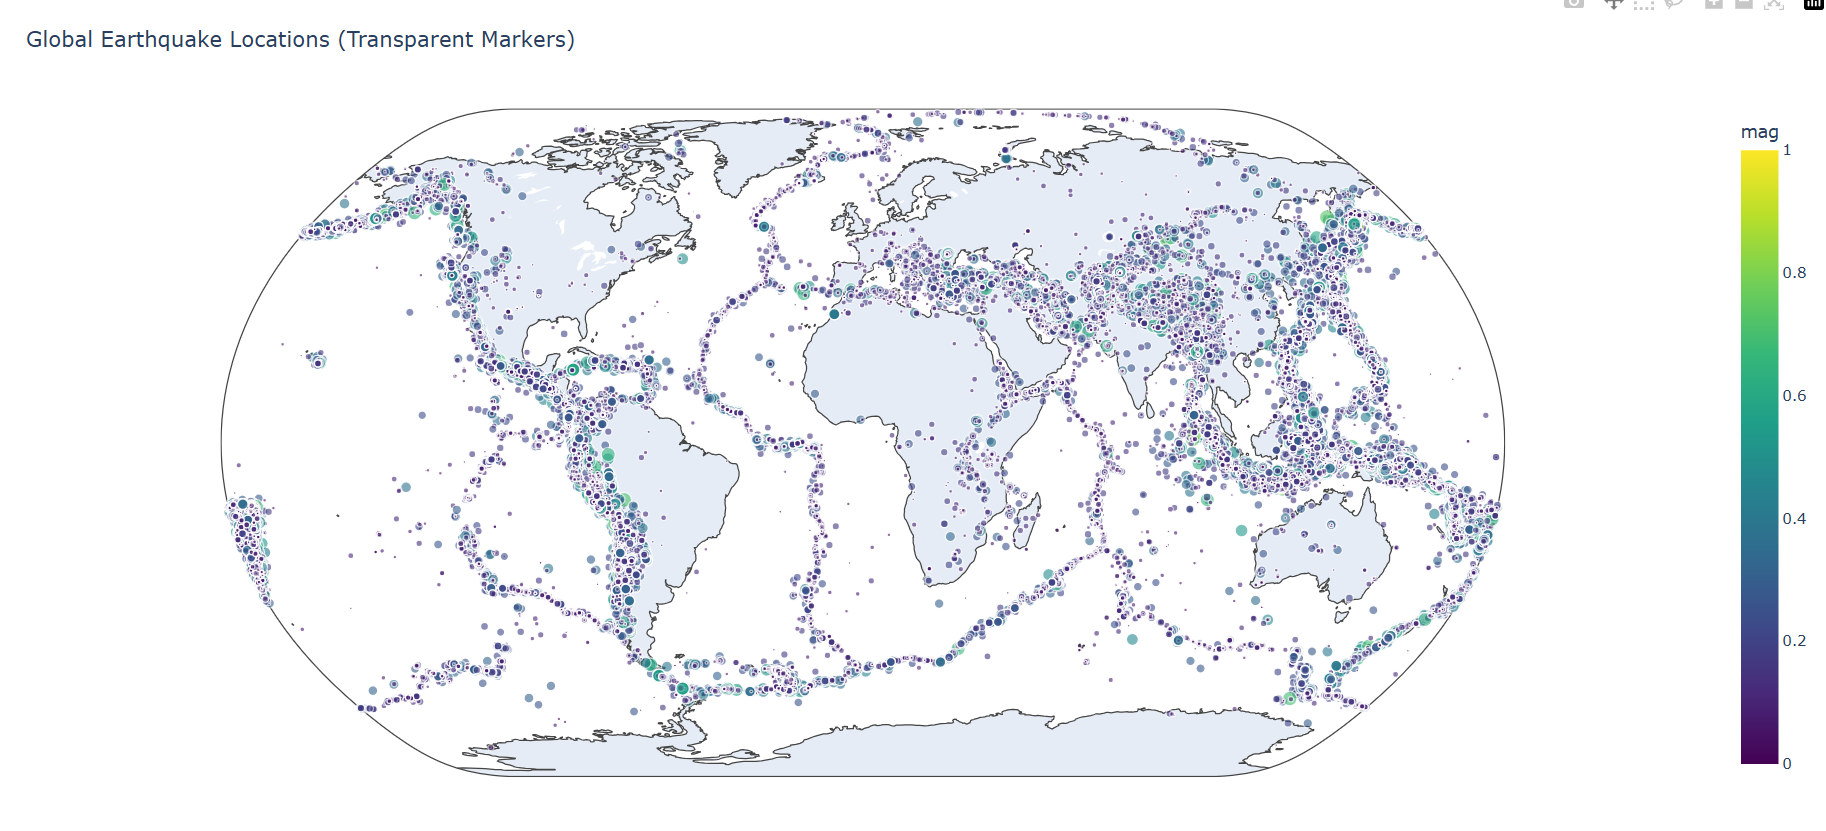

* Most earthquakes happen along plate boundaries, especially around the Pacific Ocean — this area is known as the Ring of Fire.
* The west coast of North and South America and Japan, Indonesia, and New Zealand have many strong earthquakes.
* Areas in the middle of continents have fewer earthquakes.
* Bigger and brighter dots are seen mostly near oceanic trenches and mountain regions, where plates meet or collide.